Exploring the pre-computed features generated in the endo project by the diffusion autoencoder.

In [153]:
#import pacmap
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import filters as skfilt
from scipy import interpolate as spinterp
#from vtk.util import numpy_support as vtknp
from sklearn import decomposition as skdecomp

import cellsmap.util.io as io
import cellsmap.util.pca as cmpca
import cellsmap.analyses.playground.ea.utils.io as eaio
import cellsmap.analyses.playground.ea.utils.regression as eareg
import cellsmap.analyses.playground.ea.utils.viz as eaviz

In [156]:
import sys
sys.path.append('/allen/aics/users/matheus.viana/sandbox/notebooks/')
import tools

<module 'tools' from '/allen/aics/users/matheus.viana/sandbox/notebooks/tools.py'>

In [157]:

df = pd.read_csv("/allen/aics/assay-dev/users/Erin/endo_features/pca_ref_features.csv", index_col=0)

In [176]:
df, reducer = cmpca.get_pca(df, num_pcs=3,scale=False)

df, bad_files = cmpca._get_outliers(df)
list_of_datasets = eaio.get_list_of_datasets(df,'group',verbose=True)

/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/pandas/core/frame.py:11211: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


F1: 0.9889570552147239
Cumulative Explained Variance: [0.759  0.9136 0.9939]


/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/pandas/core/frame.py:11211: RuntimeWarning: Degrees of freedom <= 0 for slice
  base_cov = np.cov(mat.T, ddof=ddof)
/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/allen/aics/assay-dev/users/Erin/git-repos/cellsmap/.venv/lib/python3.10/site-packages/numpy/lib/function_base.py:2748: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


F1: 0.9889570552147239
List of datasets represented in feature data: 
20241120_20X
20241203_20X
20241210_20X
20241217_20X


In [177]:
df.head()

,0,1,2,3,4,5,6,7,start_x,start_y,group,T,FOV_ID,description,pca_ref,outlier
248400,-0.260010,-0.205200,0.370361,0.469727,-0.474854,-0.069580,-1.512695,-0.221191,0,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False
248401,-0.232422,-0.150757,0.591797,0.594727,-0.334473,0.029022,-1.418945,-0.106812,128,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False
248402,-0.178955,-0.148438,0.721680,0.719727,-0.136230,0.051239,-1.575195,-0.079895,256,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False
248403,-0.244873,-0.198853,0.945801,0.808594,-0.087524,0.037262,-1.524414,-0.090454,384,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False
248404,-0.274170,-0.196655,0.902832,0.770508,-0.175171,0.035126,-1.442383,-0.093018,512,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False


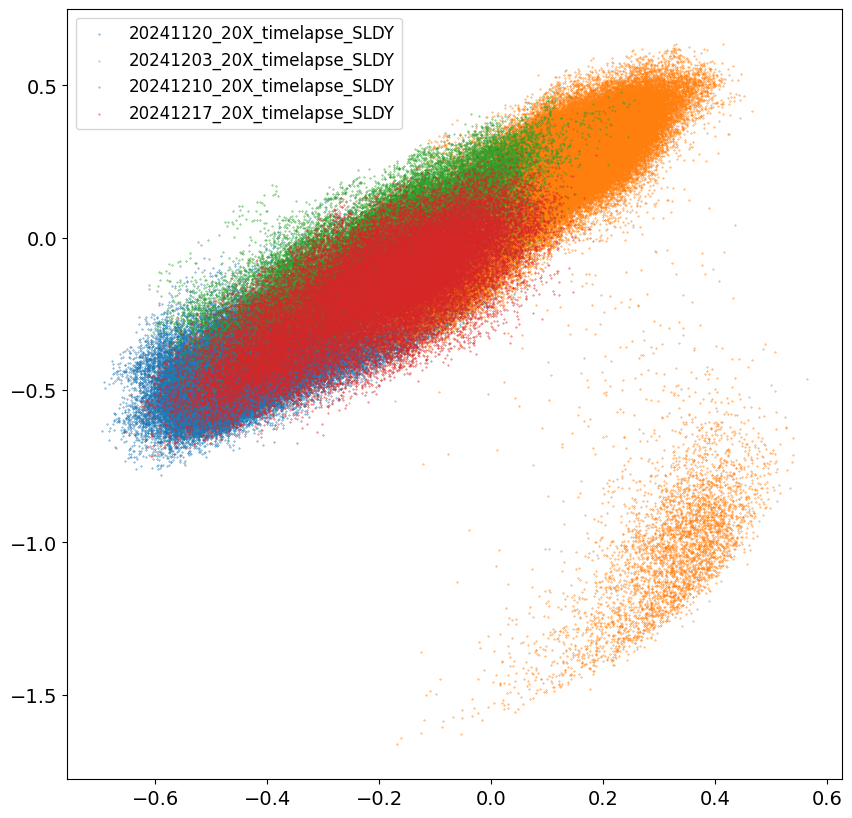

In [254]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
for (group, dfs) in df.groupby("group"):
    ax.scatter(dfs["1"], dfs["4"], s=0.1, label=group)
plt.legend()
plt.show()

In [255]:
vals = tools.simple_linear_classifier(X=df["1"].values, Y=df["4"].values)

In [256]:
df['outlier'] = vals

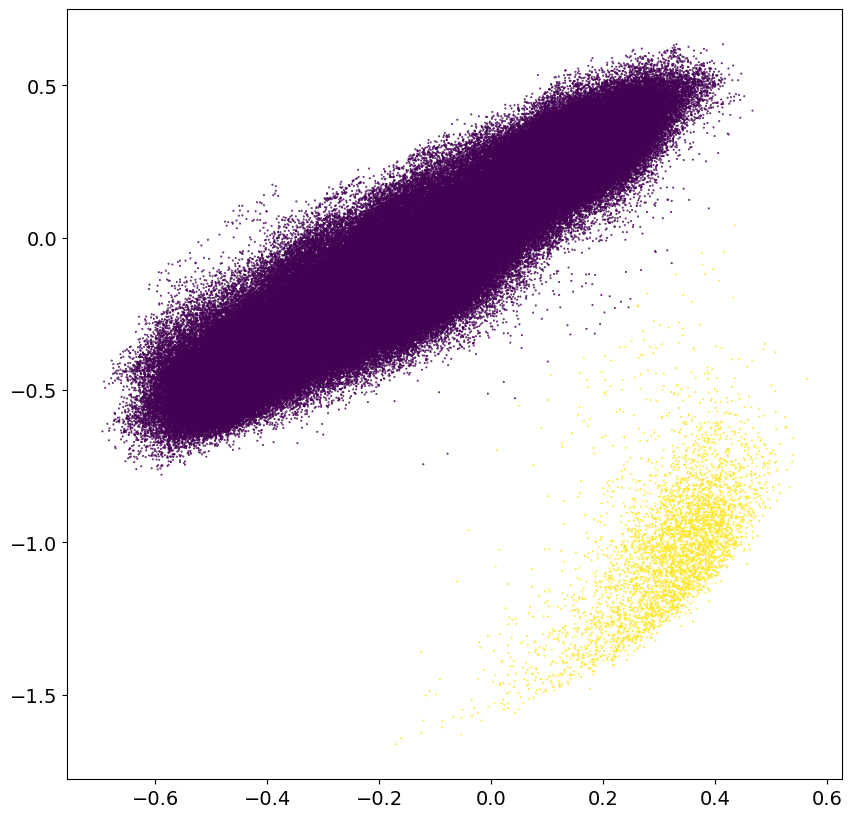

In [257]:
fig, ax = plt.subplots(1,1, figsize=(10,10))
ax.scatter(df["1"], df["4"], c=df['outlier'], s=0.2)
plt.show()

In [258]:
print(df.shape)
df["outlier"] = vals
df = df.loc[df.outlier==False]
print(df.shape)

(328752, 20)
(324558, 20)


In [259]:
X = df[[str(u) for u in range(8)]].values

In [92]:
# reducer = pacmap.PaCMAP(n_components=3, n_neighbors=10, MN_ratio=0.5, FP_ratio=2.0)
# reducer = skdecomp.PCA(n_components=3)

In [260]:
Xt = reducer.fit_transform(X)

In [261]:
for pc in range(3):
    df[f"PC{pc+1}"] = Xt[:, pc]
# df["CropId"] = df["group"] + "_" + df["FOV_ID"].astype(str) + "_" + df["start_x"].astype(str) + "_" + df["start_y"].astype(str)
# df.head()

In [262]:
df_list = []
for group in list_of_datasets:
    df_ = df.loc[df.group==group].copy()
    start_x = df_[df_['T']==df_['T'].min()]['start_x'].values.tolist()
    start_y = df_[df_['T']==df_['T'].min()]['start_y'].values.tolist()
    FOV_ID = df_[df_['T']==df_['T'].min()]['FOV_ID'].values.tolist()
    tup_list = list(zip(start_x,start_y,FOV_ID))

    def pos_to_index(x,y,FOV):
        return tup_list.index((x,y,FOV))

    df_['crop_index'] = df_.apply(lambda x: pos_to_index(x['start_x'],x['start_y'],
                                                       x['FOV_ID']),axis=1)
    df_list.append(df_)
df = pd.concat(df_list)
df.head()

,0,1,2,3,4,5,6,7,start_x,start_y,group,T,FOV_ID,description,pca_ref,outlier,PC1,PC2,PC3,crop_index
248400,-0.260010,-0.205200,0.370361,0.469727,-0.474854,-0.069580,-1.512695,-0.221191,0,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False,-0.289467,-0.452559,-0.522572,0
248616,-0.235596,-0.180908,0.376221,0.465820,-0.452881,-0.046021,-1.486328,-0.193359,0,0,20241120_20X_timelapse_SLDY,1,0,48hr High,True,False,-0.231068,-0.436836,-0.520879,0
248832,-0.268311,-0.195435,0.487549,0.543945,-0.425537,-0.028931,-1.489258,-0.178711,0,0,20241120_20X_timelapse_SLDY,2,0,48hr High,True,False,-0.249181,-0.363530,-0.401780,0
249048,-0.266357,-0.203125,0.464355,0.550293,-0.423096,-0.038818,-1.542969,-0.190186,0,0,20241120_20X_timelapse_SLDY,3,0,48hr High,True,False,-0.271548,-0.417887,-0.387392,0
249264,-0.239014,-0.199707,0.522461,0.606934,-0.348877,-0.030258,-1.607422,-0.179932,0,0,20241120_20X_timelapse_SLDY,4,0,48hr High,True,False,-0.246286,-0.437523,-0.262475,0


In [263]:
df.description.unique()

array(['48hr High', '48hr Low', '48hr No Flow (12/10/24)',
       '48hr No Flow (12/17/24)'], dtype=object)

In [264]:
xmin, xmax = np.percentile(df.PC1, [0.1, 99.9])
ymin, ymax = np.percentile(df.PC2, [0.1, 99.9])
zmin, zmax = np.percentile(df.PC3, [0.1, 99.9])

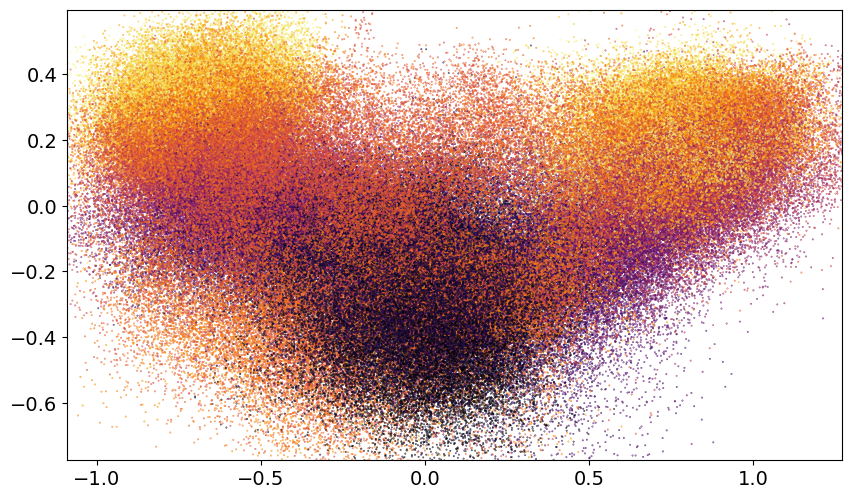

In [265]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(df.PC1, df.PC2, cmap="inferno", s=0.1, c=df["T"])
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
plt.show()

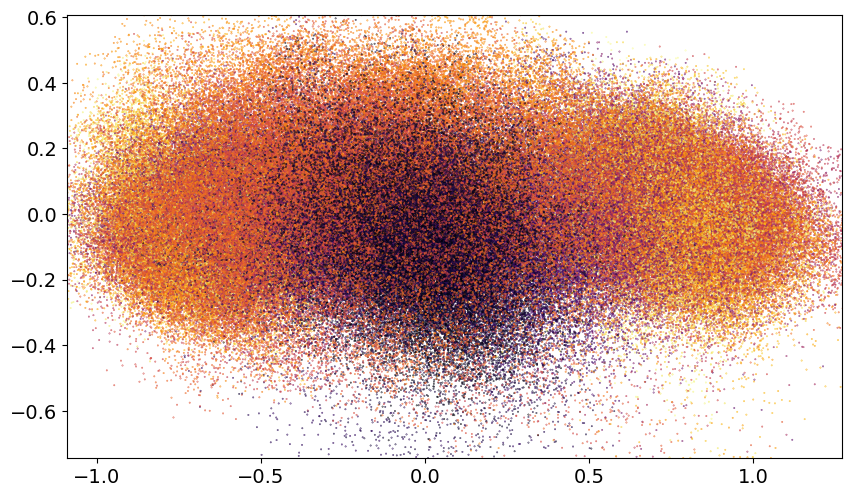

In [266]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(df.PC1, df.PC3, cmap="inferno", s=0.1, c=df["T"])
ax.set_xlim(xmin, xmax)
ax.set_ylim(zmin, zmax)
ax.set_aspect("equal")
plt.show()

/tmp/ipykernel_31873/3234565860.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(df.PC1, df.PC2, cmap="inferno", s=0.1, color="black", alpha=0.05)


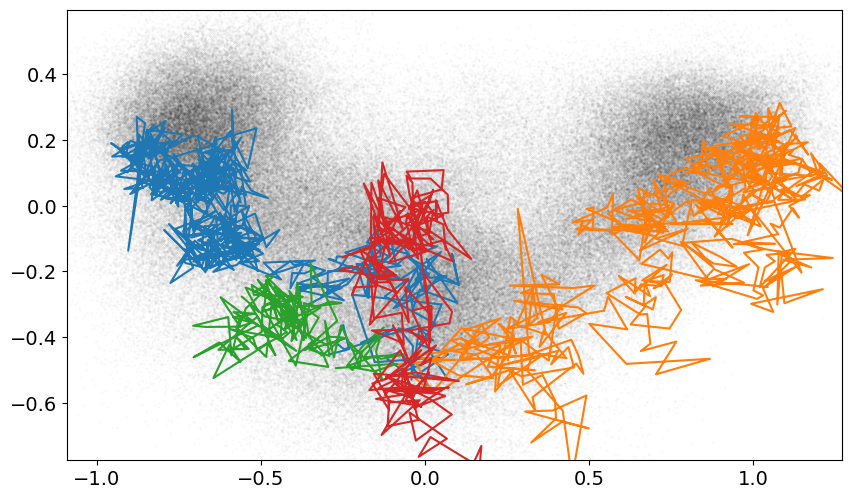

In [267]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
ax.scatter(df.PC1, df.PC2, cmap="inferno", s=0.1, color="black", alpha=0.05)
for group, df_group in df.groupby("group"):
    for track, df_track in df_group.groupby("crop_index"):
        ax.plot(df_track.PC1, df_track.PC2, label=group)
        break
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.set_aspect("equal")
plt.show()

In [268]:
df = df.sort_values(by=["group","crop_index", "T"])
df.head()

,0,1,2,3,4,5,6,7,start_x,start_y,group,T,FOV_ID,description,pca_ref,outlier,PC1,PC2,PC3,crop_index
248400,-0.260010,-0.205200,0.370361,0.469727,-0.474854,-0.069580,-1.512695,-0.221191,0,0,20241120_20X_timelapse_SLDY,0,0,48hr High,True,False,-0.289467,-0.452559,-0.522572,0
248616,-0.235596,-0.180908,0.376221,0.465820,-0.452881,-0.046021,-1.486328,-0.193359,0,0,20241120_20X_timelapse_SLDY,1,0,48hr High,True,False,-0.231068,-0.436836,-0.520879,0
248832,-0.268311,-0.195435,0.487549,0.543945,-0.425537,-0.028931,-1.489258,-0.178711,0,0,20241120_20X_timelapse_SLDY,2,0,48hr High,True,False,-0.249181,-0.363530,-0.401780,0
249048,-0.266357,-0.203125,0.464355,0.550293,-0.423096,-0.038818,-1.542969,-0.190186,0,0,20241120_20X_timelapse_SLDY,3,0,48hr High,True,False,-0.271548,-0.417887,-0.387392,0
249264,-0.239014,-0.199707,0.522461,0.606934,-0.348877,-0.030258,-1.607422,-0.179932,0,0,20241120_20X_timelapse_SLDY,4,0,48hr High,True,False,-0.246286,-0.437523,-0.262475,0


In [300]:
df_list = []
for group, df_group in df.groupby("group"):
    for crop, df_crop in df_group.groupby("crop_index"):
        diff = np.diff(df_crop[["PC1", "PC2", "PC3"]].values,axis=0)
        diff = np.vstack([diff,np.nan*np.ones(3)])
        diff = pd.DataFrame(data=diff, index=df_crop.index, columns=["dPC1", "dPC2", "dPC3"])
        df_list.append(pd.concat([df_crop, diff], axis=1))
df_vecs = pd.concat(df_list).dropna()

In [301]:
df_full = df_vecs.copy()
print(df_full.shape)

(323694, 23)


In [310]:
df_vecs = df_full.copy()
df_vecs = df_vecs.loc[df_vecs.description=="48hr Low"]
print(df_vecs.shape)

(120222, 23)


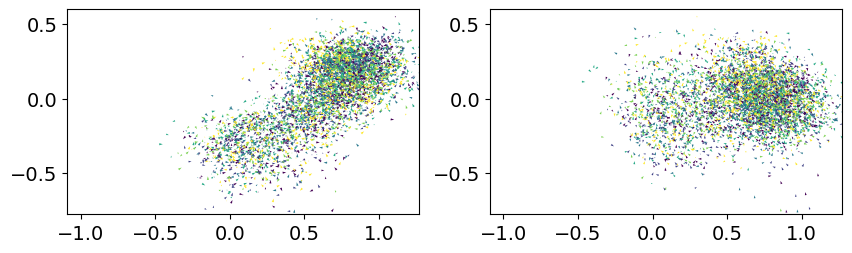

In [311]:
step = 25
U, V, Q, dU, dV, dQ = [df_vecs[col].values[::step] for col in ["PC1", "PC2", "PC3", "dPC1", "dPC2", "dPC3"]]
norm = np.sqrt(dU**2+dV**2+dQ**2)
dU = dU/norm
dV = dV/norm
dQ = dQ/norm
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(10,5))
ax1.quiver(U, V, dU, dV, df_vecs.start_y.values[::step])
ax2.quiver(U, Q, dU, dQ, df_vecs.start_y.values[::step])
for ax in [ax1, ax2]:
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect("equal")
plt.show()

In [312]:
spacing = 0.05
xgrid, ygrid, zgrid = np.meshgrid(
    np.linspace(xmin, xmax, int((xmax-xmin)/spacing)),
    np.linspace(ymin, ymax, int((ymax-ymin)/spacing)),
    np.linspace(zmin, zmax, int((zmax-zmin)/spacing)), indexing='ij')
print(xgrid.shape, ygrid.shape, zgrid.shape)

(47, 27, 27) (47, 27, 27) (47, 27, 27)


In [313]:
# points = np.transpose(np.vstack((df_vecs.xi, df_vecs.yi)))
points = np.transpose(np.vstack((U, V, Q)))
dUi = spinterp.griddata(points, dU, (xgrid, ygrid, zgrid), method='linear', fill_value=0)
dVi = spinterp.griddata(points, dV, (xgrid, ygrid, zgrid), method='linear', fill_value=0)
dQi = spinterp.griddata(points, dQ, (xgrid, ygrid, zgrid), method='linear', fill_value=0)

In [314]:
dUis = skfilt.gaussian(dUi, sigma=3, preserve_range=True)
dVis = skfilt.gaussian(dVi, sigma=3, preserve_range=True)
dQis = skfilt.gaussian(dQi, sigma=3, preserve_range=True)

In [315]:
epson = 1e-18
norm = np.sqrt(epson+dUis**2+dVis**2+dQis**2)
dUis /= norm
dVis /= norm
dQis /= norm

2538


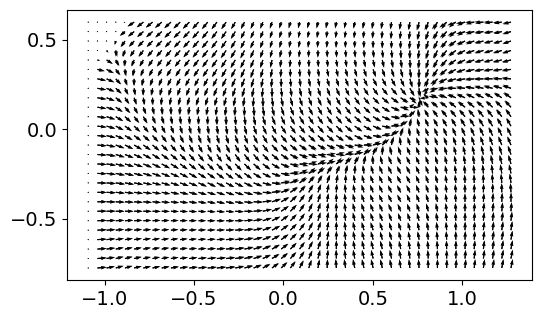

In [316]:
pc3val = 0.0
zgridmin = pc3val-0.8*spacing
zgridmax = pc3val+1.2*spacing
valids = np.where((zgrid.ravel()>zgridmin)&(zgrid.ravel()<zgridmax)); print(len(valids[0]))
fig, ax = plt.subplots(1,1, figsize=(6,6))
ax.quiver(xgrid.ravel()[valids], ygrid.ravel()[valids], dUis.ravel()[valids], dVis.ravel()[valids], scale=50)
ax.set_aspect("equal")
plt.show()

In [110]:
img = tools.create_vector_field_imagedata(-dUis, -dVis, -dQis)

In [111]:
tools.save_image_data(img)

In [187]:
def save_points_as_polydata(coordinates, tp=0):
    pts = vtk.vtkPoints()
    pts.SetData(vtknp.numpy_to_vtk(coordinates))
    poly = vtk.vtkPolyData()
    poly.SetPoints(pts)
    writer = vtk.vtkPolyDataWriter()
    writer.SetInputData(poly)
    writer.SetFileName(f"anim_{tp:05}.vtk")
    writer.Write()

In [196]:
!rm anim*.vtk

In [232]:
n = 50
coord = [
    [((vmax-vmin)/spacing)*np.random.rand() for (vmin, vmax) in [(xmin, xmax), (ymin, ymax), (zmin, zmax)]
] for _ in range(n)]
coord = np.array(coord)
print(coord.shape)

(50, 3)


In [233]:
save_points_as_polydata(coordinates=coord)

In [234]:
eps = 2
speed = 0.5
for tp in range(1, 50):
    
    coord_new = []
    for r in coord:
        x, y, z = r
        vx = dUis[int(x), int(y), int(z)]
        vy = dVis[int(x), int(y), int(z)]
        vz = dQis[int(x), int(y), int(z)]
        x_new = x - speed * vx
        y_new = y - speed * vy
        z_new = z - speed * vz

        x_new = (x_new + eps) % ((xmax-xmin)/spacing) - eps
        y_new = (y_new + eps) % ((ymax-ymin)/spacing) - eps
        z_new = (z_new + eps) % ((zmax-zmin)/spacing) - eps

        coord_new.append([x_new, y_new, z_new])
    
    coord = np.array(coord_new).copy()
    save_points_as_polydata(coordinates=coord, tp=tp)